In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive/')
PROJECT_DIR = "/content/drive/MyDrive/aptos_project"
os.makedirs(PROJECT_DIR, exist_ok=True)

Mounted at /content/drive/


In [ ]:
from google.colab import files
files.upload()

KeyboardInterrupt: 

In [ ]:
!ls -l ~/.kaggle/kaggle.json

In [ ]:
!mkdir -p /root/.kaggle
!cp "kaggle.json" /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

# 1. Loading Data

In [ ]:
!unzip -q "{DATA_DIR}/aptos2019-blindness-detection.zip" -d "{DATA_DIR}"

In [ ]:
import os

!kaggle competitions download -c aptos2019-blindness-detection -p "{DATA_DIR}"

#2. Data Exploration

In [ ]:
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/aptos_project"
DATA_DIR = f"{PROJECT_DIR}/data"
train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test.csv")

train_df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [ ]:
os.listdir(f"{DATA_DIR}")

['sample_submission.csv',
 'test.csv',
 'train.csv',
 'aptos2019-blindness-detection.zip',
 'test_images',
 'train_images']

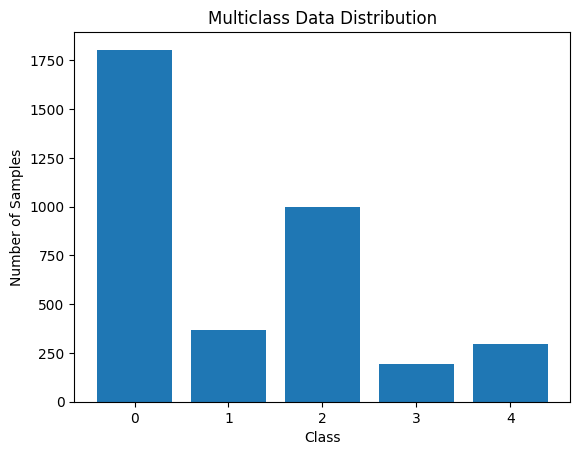

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

count = Counter(train_df['diagnosis'])

plt.bar(count.keys(), count.values())
plt.title('Multiclass Data Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.show()

Class imbalance- since 0 indicates no DR and 1-4 indicates presence of DR, we can first investigate whether a model can detect presence of DR with binary classification.

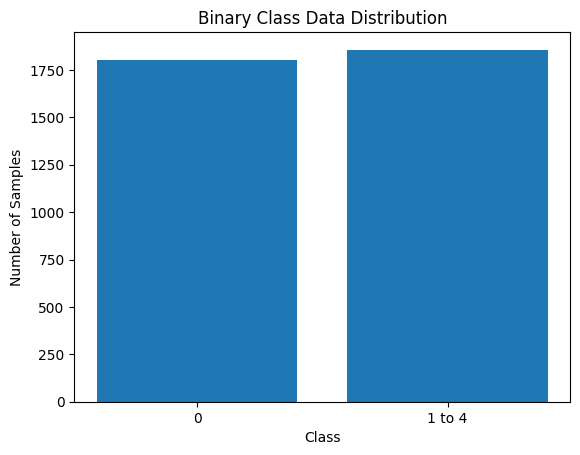

In [ ]:
grouped = Counter({"0": count[0],
    "1 to 4": count[1] + count[2] + count[3] + count[4]
})
grouped

plt.bar(list(grouped.keys()), grouped.values())
plt.title("Binary Class Data Distribution")
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.show()

# 3. Data Cleaning

KeyboardInterrupt: 

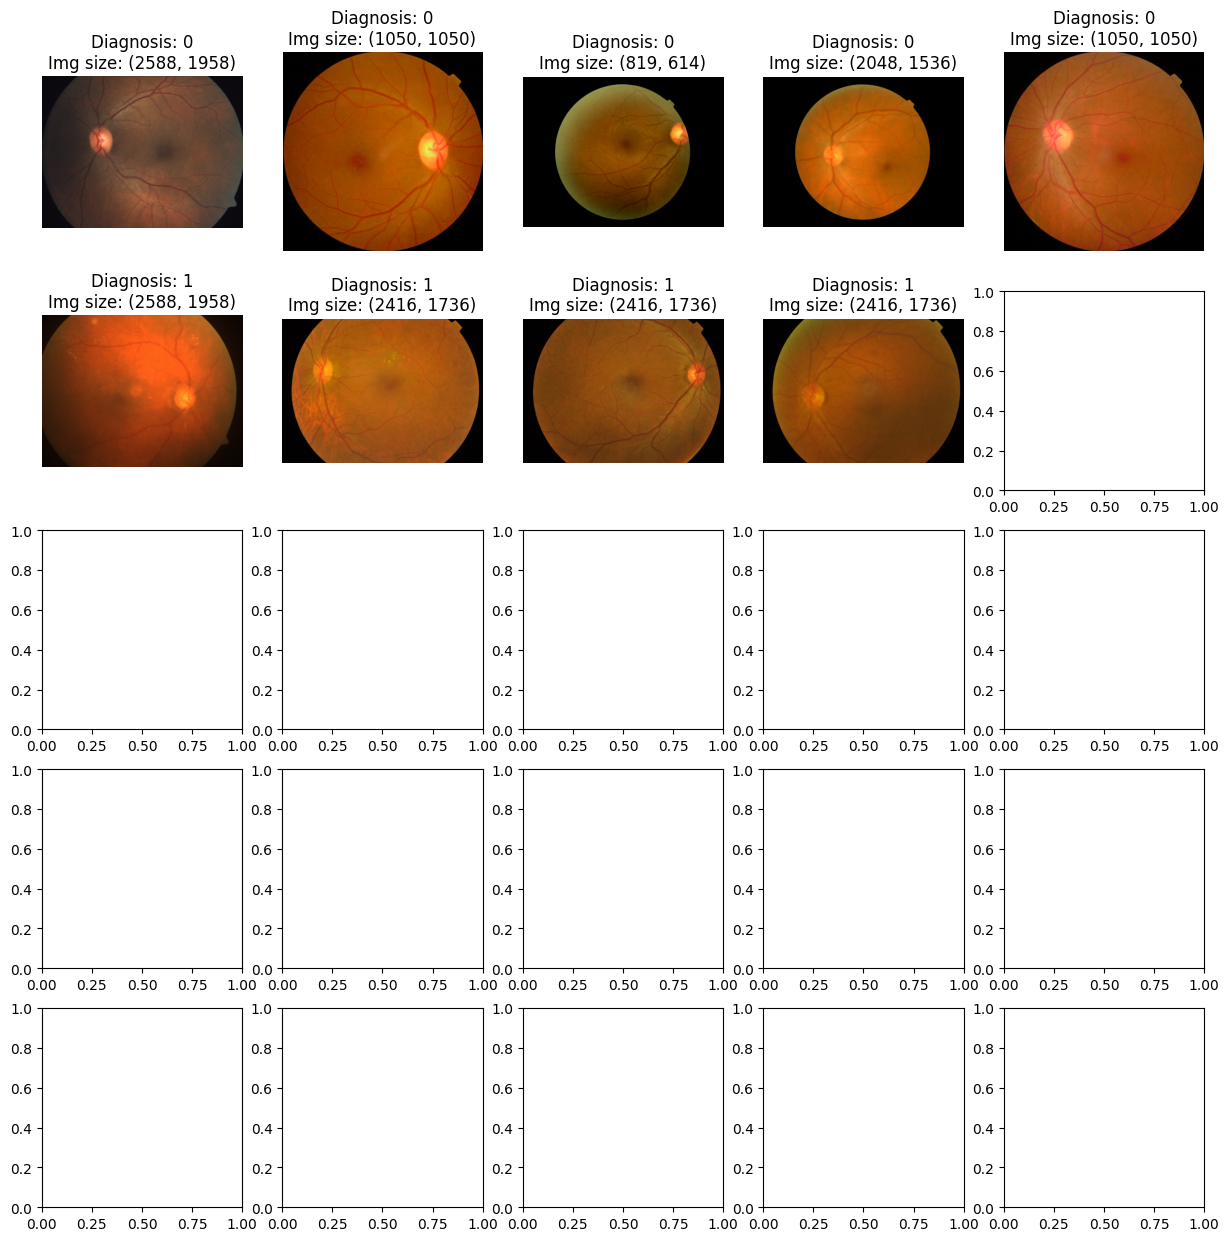

In [ ]:
from PIL import Image

fig, axes = plt.subplots(5, 5, figsize=(15, 15))

png_files = []
labels = []

for i in range(5):
    samples = train_df[train_df["diagnosis"] == i].sample(n=5, random_state=1)["id_code"]

    for sample in samples:
        png_files.append(f"{DATA_DIR}/train_images/{sample}.png")
        labels.append(i)

for ax, img_path, label in zip(axes.ravel(), png_files, labels):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"Diagnosis: {label}\n"
                 f"Img size: {img.size}")
    ax.axis("off")

plt.tight_layout()
plt.show()
print(png_files)

Considerations:
1.   Different image sizes- CNNs need consistent image input sizes
2.   Cameras pick up different colors- Different cameras can pick up different lighting and clarity, the model may learn camera differences instead of disease features.
3.   Black border- not medically useful and model again may learn patterns in black borders
4.   Class imbalance- will first attempt to fit a binary classifier because binary classes (DR vs. No DR) are balanced



In [ ]:
import cv2
import numpy as np

def crop_retina(im, tol=20, pad=10):
    # Make sure image is RGB
    im = im.convert("RGB")
    arr = np.array(im)

    # Convert to grayscale
    gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)

    # Find non-black pixels
    mask = gray > tol

    # If image is somehow empty, return original
    if not mask.any():
        return im

    # Find coordinates of non-black region
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1

    # Add padding so we do not crop into the retina
    y0 = max(y0 - pad, 0)
    x0 = max(x0 - pad, 0)
    y1 = min(y1 + pad, arr.shape[0])
    x1 = min(x1 + pad, arr.shape[1])

    # Crop image
    cropped = im.crop((x0, y0, x1, y1))

    return cropped

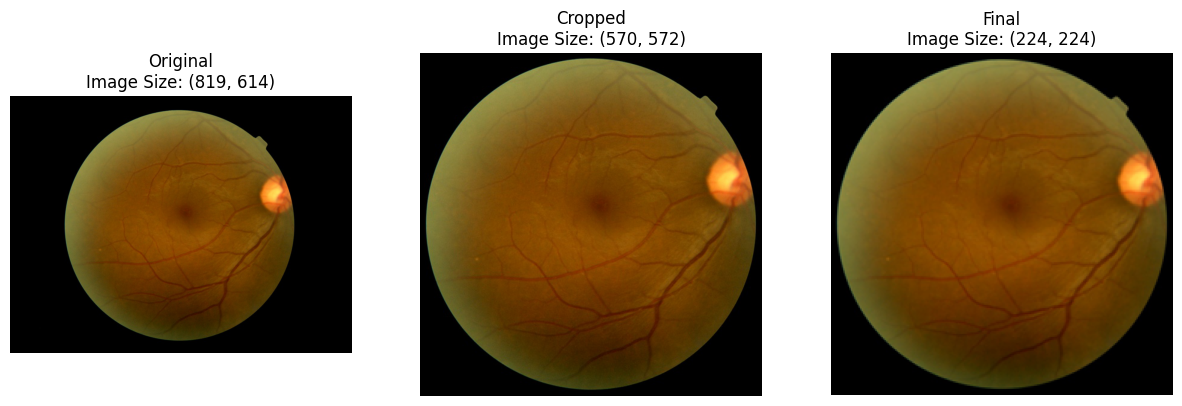

In [ ]:
# Example
path = "/content/drive/MyDrive/aptos_project/data/train_images/da0a83f074f3.png"

img = Image.open(path).convert("RGB")
cropped = crop_retina(img, tol=20, pad=10)
final_img = cropped.resize((224, 224))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original\n"
          f"Image Size: {img.size}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cropped)
plt.title("Cropped\n"
        f"Image Size: {cropped.size}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(final_img)
plt.title("Final\n"
        f"Image Size: {final_img.size}")
plt.axis("off")

plt.show()

# 4. Binary Classification

## 4.1 Loading Data

In [ ]:
train_df["binary_label"] = train_df["diagnosis"].apply(lambda x: 0 if x == 0 else 1)
train_df["binary_label"].value_counts()

,count
binary_label,
1,1857
0,1805


In [ ]:
from sklearn.model_selection import train_test_split

# binary label: 0 = no DR, 1 = any DR
train_df["binary_label"] = train_df["diagnosis"].apply(lambda x: 0 if x == 0 else 1)

# First split off test set: 20%
train_val_df, test_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["binary_label"],
    random_state=42
)

# Then split remaining into train/val
train_data, val_data = train_test_split(
    train_val_df,
    test_size=0.2,
    stratify=train_val_df["binary_label"],
    random_state=42
)

train_data.shape, val_data.shape, test_df.shape
train_data.head()

,id_code,diagnosis,binary_label
2567,b187b3c93afb,2,1
2240,9d9bfefa809c,2,1
1499,6966abf40b8c,0,0
2552,b0acd3593310,0,0
1622,7269a1d84a57,0,0


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

class APTOSDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_id = self.dataframe.loc[idx, "id_code"]
        img_path = os.path.join(self.img_dir, img_id + ".png")
        image = Image.open(img_path).convert("RGB")

        # crop black border
        image = crop_retina(image, tol=20, pad=10)
        label = self.dataframe.loc[idx, "binary_label"]

        if self.transform:
            image = self.transform(image)

        return image, label



train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    # random augmentations for training only
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
IMG_DIR = f"{DATA_DIR}/train_images"

train_dataset = APTOSDataset(train_data, IMG_DIR, transform=train_transform)
val_dataset = APTOSDataset(val_data, IMG_DIR, transform=val_transform)
test_dataset = APTOSDataset(test_df, IMG_DIR, transform=val_transform)

img, label = train_dataset[0]

print(type(img))
print(img.shape)
print(label)


<class 'torch.Tensor'>
torch.Size([3, 224, 224])
1


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

## 4.2 Training Data

In [ ]:
import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim
from tqdm.notebook import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 20

train_losses = []
val_losses = []
val_accs = []
sensitivities = []
specificities = []

best_val_loss = float("inf")

SAVE_DIR = "/content/drive/MyDrive/aptos_project/models"
os.makedirs(SAVE_DIR, exist_ok=True)
best_model_path = f"{SAVE_DIR}/best_resnet18_binary.pth"

for epoch in range(num_epochs):
    # -------------------
    # Training
    # -------------------
    model.train()
    running_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}")

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        progress_bar.set_postfix(loss=loss.item())

    avg_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # -------------------
    # Validation
    # -------------------
    model.eval()

    val_running_loss = 0.0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(val_loader, desc="Validating")

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_running_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    accuracy = accuracy_score(all_labels, all_preds)
    val_accs.append(accuracy)

    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    sensitivities.append(sensitivity)
    specificities.append(specificity)

    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))

    # Save best model based on validation loss
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        print("Saved new best model.")

cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 22.8MB/s]


Epoch 1/20:   0%|          | 0/147 [00:00<?, ?it/s]

KeyboardInterrupt: 

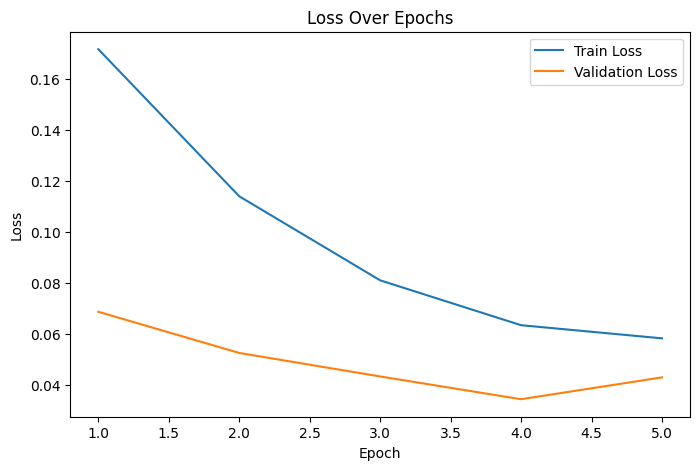

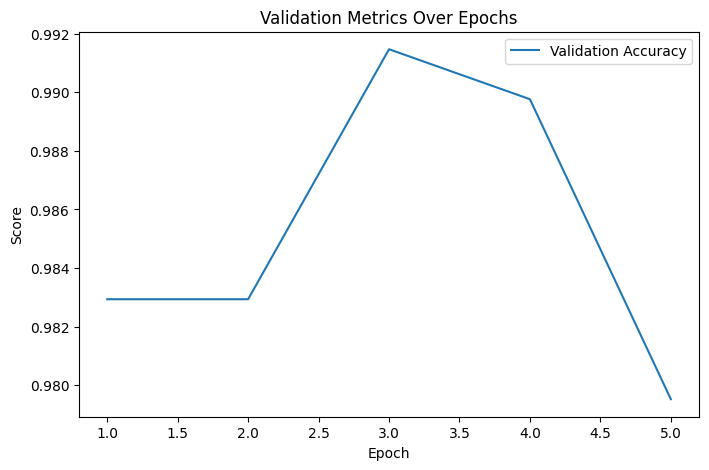

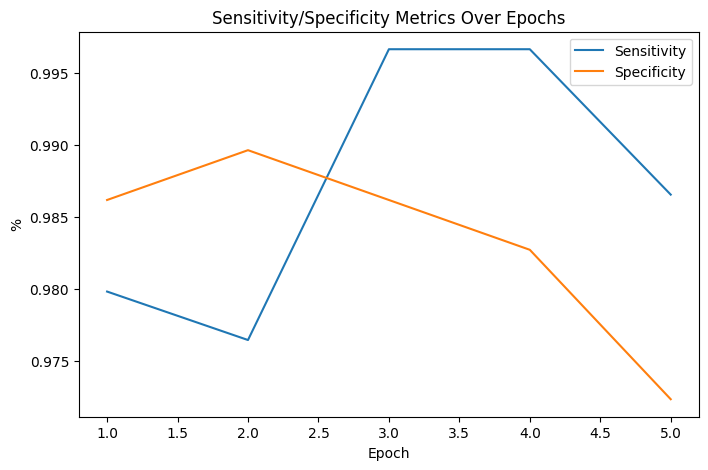

In [ ]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics Over Epochs")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, sensitivities, label="Sensitivity")
plt.plot(epochs, specificities, label="Specificity")
plt.xlabel("Epoch")
plt.ylabel("%")
plt.title("Sensitivity/Specificity Metrics Over Epochs")
plt.legend()
plt.show()



In [ ]:
print("Model saved?", os.path.exists(best_model_path))
print("Saved at:", best_model_path)

Model saved? True
Saved at: /content/drive/MyDrive/aptos_project/models/best_resnet18_binary.pth


In [ ]:
test_df.head()

,id_code,diagnosis,binary_label
2666,b8e9a8f4617d,0,0
38,02dda30d3acf,4,1
3463,f06e7a9df795,0,0
962,44e0d56e9d42,2,1
3248,e1dc02a3dc2a,0,0


In [ ]:
# Import model

import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)  ## Change for multi class

# Change to final model path
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/aptos_project/models/best_resnet18_binary.pth",
    map_location=device
))
model = model.to(device)
model.eval()

print("Model loaded successfully!")

from tqdm.notebook import tqdm
import numpy as np

all_preds = []
all_probs = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # P(DR)
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

print("Done predicting.")
print("First 10 predictions:", all_preds[:10])
print("First 10 DR probabilities:", all_probs[:10])

from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

accuracy = accuracy_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

print("Test Accuracy:", accuracy)
print("Test AUC:", auc)

print("\nConfusion Matrix:")
cm = confusion_matrix(all_labels, all_preds)
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["NoDR", "DR"]))

tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Sensitivity / DR Recall:", sensitivity)
print("Specificity / NoDR Recall:", specificity)

Using device: cpu
Model loaded successfully!


  0%|          | 0/46 [00:00<?, ?it/s]

Done predicting.
First 10 predictions: [0 1 0 1 0 0 0 1 1 1]
First 10 DR probabilities: [8.0461296e-06 9.9995053e-01 1.1207024e-03 9.9961108e-01 8.4679120e-04
 1.6625957e-03 8.2198280e-04 9.9999976e-01 9.9999249e-01 9.9938989e-01]
Test Accuracy: 0.9727148703956344
Test AUC: 0.9972708724272481

Confusion Matrix:
[[344  17]
 [  3 369]]

Classification Report:
              precision    recall  f1-score   support

        NoDR       0.99      0.95      0.97       361
          DR       0.96      0.99      0.97       372

    accuracy                           0.97       733
   macro avg       0.97      0.97      0.97       733
weighted avg       0.97      0.97      0.97       733

Sensitivity / DR Recall: 0.9919354838709677
Specificity / NoDR Recall: 0.9529085872576177
